In [1]:
import os
import sys

sys.path.append(os.path.abspath(".."))

from src.charts.catch_up_inequality import (
    create_catch_up_change_heatmap,
    create_catch_up_levels_chart,
)
from src.constants import (
    QILT_2024_GOS_L_SOURCE,
    QILT_2024_GOS_SOURCE,
    QILT_FOLDER_NAME,
)
from src.preparation.qilt import prepare_qilt_table
from src.transform.catch_up_inequality import (
    build_catch_up_gap_width_table,
    build_catch_up_levels_table,
)
from src.types import ExcelSheet

# Data loading — source workbook selections for the secondary catch-up charts
gos_demographic_sheet_name = "EMP_UG_ALL_2Y_DG"  # GOS 9
gos_l_demographic_sheet_name = "STMT_UG_ALL_1Y_SG"  # GOS-L 161

In [2]:
# Data loading — workbook/sheet definitions
gos_demographic_sheet = ExcelSheet(
    folder=QILT_FOLDER_NAME,
    data_source=QILT_2024_GOS_SOURCE,
    sheet_name=gos_demographic_sheet_name,
)
gos_l_demographic_sheet = ExcelSheet(
    folder=QILT_FOLDER_NAME,
    data_source=QILT_2024_GOS_L_SOURCE,
    sheet_name=gos_l_demographic_sheet_name,
)

In [3]:
# Data loading — clean the QILT tables used by the secondary catch-up charts
gos_demographic_table = prepare_qilt_table(
    gos_demographic_sheet.folder,
    gos_demographic_sheet.file_name,
    gos_demographic_sheet.sheet_name,
)
gos_l_demographic_table = prepare_qilt_table(
    gos_l_demographic_sheet.folder,
    gos_l_demographic_sheet.file_name,
    gos_l_demographic_sheet.sheet_name,
)

In [4]:
# Table building

# Report part 3 — The later picture may improve, but not necessarily equally
# Secondary/supporting EDA chart
# Answers: What do the raw subgroup levels look like before and alongside the gap-based view?
catch_up_levels_table = build_catch_up_levels_table(
    gos_demographic_table,
    gos_l_demographic_table,
)

# Report part 3 — The later picture may improve, but not necessarily equally
# Secondary/supporting EDA chart
# Answers: What is the main gap-order reference used to keep the support charts aligned with the presentation chart?
catch_up_gap_width_table = build_catch_up_gap_width_table(catch_up_levels_table)
row_group_order = catch_up_gap_width_table.loc[
    catch_up_gap_width_table["outcome_key"] == "full_time_employment",
    "row_group",
].tolist()

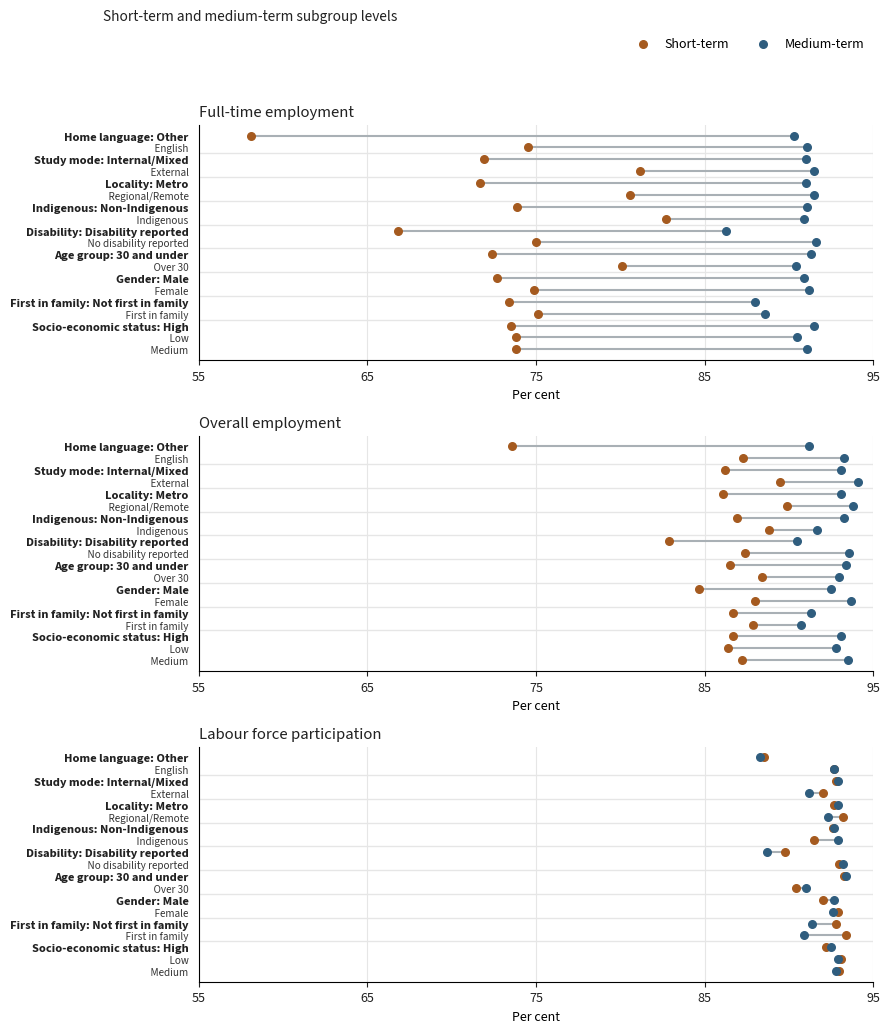

In [5]:
# Secondary chart generation

# Report part 3 — The later picture may improve, but not necessarily equally
# Secondary/supporting EDA chart
# Answers: What are the raw subgroup levels before or alongside the gap-closure view?
levels_figure = create_catch_up_levels_chart(catch_up_levels_table, row_group_order=row_group_order)
levels_figure

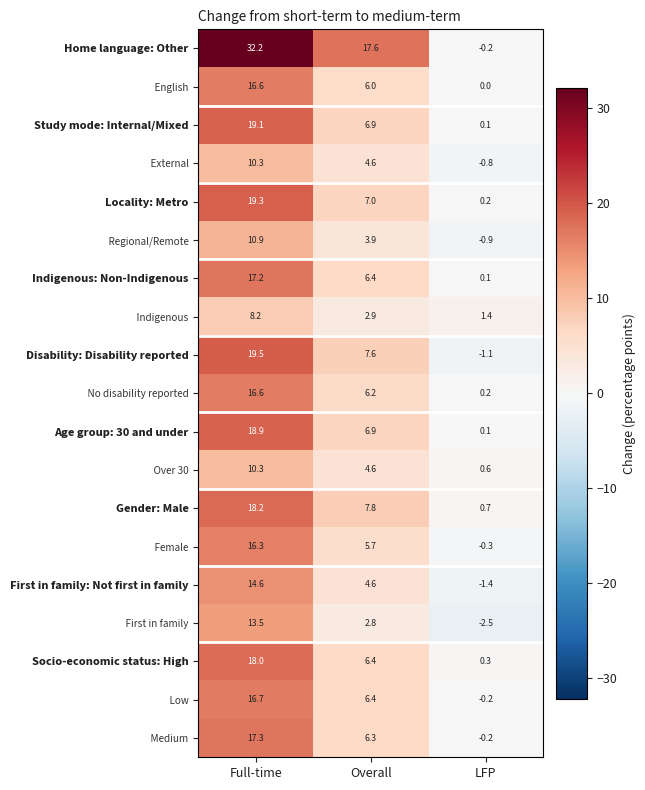

In [6]:
# Report part 3 — The later picture may improve, but not necessarily equally
# Secondary/supporting EDA chart
# Answers: How much does each subgroup level change in absolute terms, even when that does not directly show gap closure?
change_heatmap_figure = create_catch_up_change_heatmap(catch_up_levels_table, row_group_order=row_group_order)
change_heatmap_figure